In [1]:
!pip list | grep torch

torch                              2.5.1
torchaudio                         2.5.1
torchvision                        0.20.1


In [2]:
import os
import site
import sys

# Use conda PyTorch (cu124) — ignore ~/.local torch (cu130 breaks this GPU driver)
os.environ["PYTHONNOUSERSITE"] = "1"
site.ENABLE_USER_SITE = False
sys.path = [p for p in sys.path if "/.local/" not in p.replace("\\", "/")]
_deps = '/workspace/home/docker-cuda-netbird/MTAI2026-Deep-learning-frameworks-seminars/.seminar_deps'
if os.path.isdir(_deps) and _deps not in sys.path:
    sys.path.append(_deps)

import torch
print('torch', torch.__version__, 'cuda', torch.cuda.is_available())


torch 2.5.1+cu124 cuda True


*   https://pytorch.org/blog/quantization-in-practice/
*   https://pytorch.org/docs/stable/quantization.html
*   https://pytorch.org/docs/stable/quantization-support.html

### Mapping function and Quantization Parameters

In [3]:
# r - float tensor, r' - int tensor
# S [scaling factor] = (beta - alpha) / (beta_q - alpha_q)
# Z [zero point] =  -(alpha / S - alpha_q)

def quantize(float_tensor, scale, z):
  # Q(r) = round(r/S + Z)
  return torch.round(float_tensor / scale + z)

def dequantize(int_tensor, scale, z):
  # r' = (Q(r) - Z) * S
  return (int_tensor - z) * scale

In [4]:
from torch.ao.quantization.observer import MinMaxObserver, MovingAverageMinMaxObserver, HistogramObserver

C, L = 3, 4
normal = torch.distributions.normal.Normal(0,1)
inputs = normal.sample((C, L))
print(inputs)

tensor([[ 0.1906,  2.7187, -0.9268, -0.0047],
        [-0.9358, -0.8732,  0.0758, -2.3392],
        [ 1.3483,  0.8969, -0.3626,  1.1106]])


In [5]:
observers = [MinMaxObserver(), MovingAverageMinMaxObserver(), HistogramObserver()]
for obs in observers:
  obs(inputs)
  print(obs.__class__.__name__, obs.calculate_qparams())

MinMaxObserver (tensor([0.0198]), tensor([118], dtype=torch.int32))
MovingAverageMinMaxObserver (tensor([0.0198]), tensor([118], dtype=torch.int32))
HistogramObserver (tensor([0.0198]), tensor([118], dtype=torch.int32))


In [6]:
scale, z = observers[0].calculate_qparams()
reconstruction_error = torch.abs(dequantize(quantize(inputs, scale, z), scale, z) - inputs)
reconstruction_error

tensor([[0.0078, 0.0013, 0.0055, 0.0047],
        [0.0035, 0.0004, 0.0036, 0.0013],
        [0.0005, 0.0044, 0.0056, 0.0001]])

### Affine and Symmetric Quantization Schemes

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def get_symmetric_range(x):
  beta = torch.max(x.max(), x.min().abs())
  return -beta.item(), beta.item()

def get_affine_range(x):
  return x.min().item(), x.max().item()

def plot(plt, data, scheme):
  boundaries = get_affine_range(data) if scheme == 'affine' else get_symmetric_range(data)
  a, _, _ = plt.hist(data, density=True, bins=100)
  ymin, ymax = np.quantile(a[a>0], [0.25, 0.95])
  plt.vlines(x=boundaries, ls='--', colors='purple', ymin=ymin, ymax=ymax)

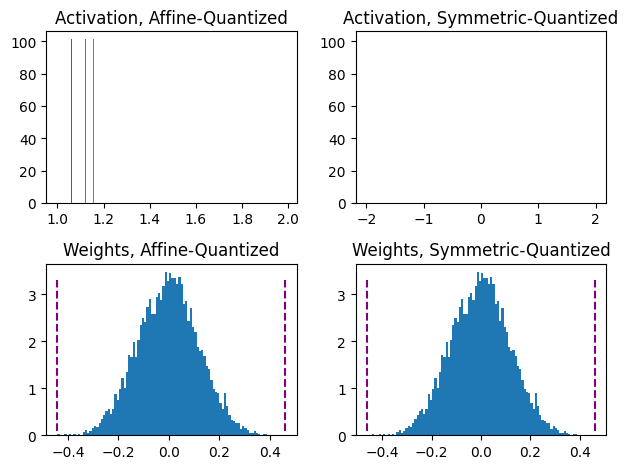

In [8]:
act =  torch.distributions.pareto.Pareto(1, 10).sample((1, 1024))
weights = torch.distributions.normal.Normal(0, 0.12).sample((3, 64, 7, 7)).flatten()

fig, axs = plt.subplots(2,2)
plot(axs[0, 0], act, 'affine')
axs[0, 0].set_title("Activation, Affine-Quantized")

plot(axs[0, 1], act, 'symmetric')
axs[0, 1].set_title("Activation, Symmetric-Quantized")

plot(axs[1, 0], weights, 'affine')
axs[1, 0].set_title("Weights, Affine-Quantized")

plot(axs[1, 1], weights, 'symmetric')
axs[1, 1].set_title("Weights, Symmetric-Quantized")

fig.tight_layout()
plt.show()

In [9]:
for qscheme in [torch.per_tensor_affine, torch.per_tensor_symmetric]:
  obs = MovingAverageMinMaxObserver(qscheme=qscheme)
  obs(inputs)
  print(f"Qscheme: {qscheme} | {obs.calculate_qparams()}")

Qscheme: torch.per_tensor_affine | (tensor([0.0198]), tensor([118], dtype=torch.int32))
Qscheme: torch.per_tensor_symmetric | (tensor([0.0213]), tensor([128]))


### Per-Tensor and Per-Channel Quantization Schemes

In [10]:
from torch.ao.quantization.observer import MovingAveragePerChannelMinMaxObserver

obs = MovingAveragePerChannelMinMaxObserver(ch_axis = 0)  # calculate qparams for all `C` channels separately
obs(inputs)
print(obs.calculate_qparams())

(tensor([0.0143, 0.0095, 0.0067]), tensor([ 65, 247,  54], dtype=torch.int32))


For weights quantization, symmetric-per-channel quantization provides better accuracies; per-tensor quantization performs poorly, possibly due to high variance in conv weights across channels from batchnorm folding.
[https://arxiv.org/abs/2004.09602]

https://github.com/pytorch/pytorch/blob/748d9d24940cd17938df963456c90fa1a13f3932/torch/ao/quantization/observer.py#L258

### Backend Engine

In [11]:
backend = 'fbgemm' #'fbgemm' if x86 else 'qnnpack' intel - oneDNN
qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.backends.quantized.engine = backend

GPUs - via TensorRT and cuDNN
https://pytorch.org/docs/stable/quantization.html#note-for-native-cpu-backends

### QConfig

In [12]:
my_qconfig = torch.ao.quantization.QConfig(
  activation=MovingAverageMinMaxObserver.with_args(qscheme=torch.per_tensor_affine),
  weight=MovingAveragePerChannelMinMaxObserver.with_args(qscheme=torch.qint8))

my_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, qscheme=torch.per_tensor_affine){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MovingAveragePerChannelMinMaxObserver'>, qscheme=torch.qint8){})

### Eager Mode v/s FX Graph Mode

*    Eager Mode Quantization is a beta feature. User needs to do fusion and specify where quantization and dequantization happens manually, also it only supports modules and not functionals.
*    FX Graph Mode Quantization is a new automated quantization framework in PyTorch, and currently it’s a prototype feature. It improves upon Eager Mode Quantization by adding support for functionals and automating the quantization process, although people might need to refactor the model to make the model compatible with FX Graph Mode Quantization (symbolically traceable with torch.fx)






FX Graph Mode automatically fuses eligible modules, inserts Quant/DeQuant stubs, calibrates the model and returns a quantized module - all in two method calls - but only for networks that are symbolic traceable. The examples below contain the calls using Eager Mode and FX Graph Mode for comparison.
https://pytorch.org/docs/stable/fx.html#torch.fx.symbolic_trace

In [13]:
def f(a, b):
    if b == True:
        return a
    else:
        return a * 2

In [14]:
f = torch.fx.symbolic_trace(f, concrete_args={'b': False})
# b is specialized to False during tracing, so keep the same value at call time.
assert f(3, False) == 6

https://pytorch.org/docs/stable/fx.html

### Post-Training Dynamic/Weight-only Quantization

Here the model’s weights are pre-quantized; the activations are quantized on-the-fly (“dynamic”) during inference. The simplest of all approaches, it has a one line API call in torch.quantization.quantize_dynamic. Currently only Linear and Recurrent (LSTM, GRU, RNN) layers are supported for dynamic quantization



*   Can result in higher accuracies since the clipping range is exactly calibrated for each input
*   Calibrating and quantizing the activations at each layer during runtime can add to the compute overhead



In [15]:
from torch import nn

# toy model
m = nn.Sequential(
  nn.Conv2d(2, 64, (8,)),
  nn.ReLU(),
  nn.Linear(16, 10),
  nn.LSTM(10, 10))

m.eval()

Sequential(
  (0): Conv2d(2, 64, kernel_size=(8,), stride=(1, 1))
  (1): ReLU()
  (2): Linear(in_features=16, out_features=10, bias=True)
  (3): LSTM(10, 10)
)

In [16]:
## EAGER MODE
from torch.ao.quantization import quantize_dynamic

model_quantized = quantize_dynamic(
    model=m, qconfig_spec={nn.LSTM, nn.Linear}, dtype=torch.qint8, inplace=False
)

In [17]:
## FX MODE
from torch.ao.quantization import quantize_fx

example_inputs = (torch.randn(1, 3, 224, 224),)
qconfig_dict = {"": torch.ao.quantization.default_dynamic_qconfig}  # An empty key denotes the default applied to all modules
model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)
model_quantized = quantize_fx.convert_fx(model_prepared)

/opt/miniconda3/lib/python3.10/site-packages/torch/ao/quantization/quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported in a future version. Please pass in a QConfigMapping instead.
  prepared = prepare(
/opt/miniconda3/lib/python3.10/site-packages/torch/ao/nn/quantized/reference/modules/rnn.py:455: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(
/opt/miniconda3/lib/python3.10/site-packages/torch/ao/nn/quantized/reference/modules/rnn.py:461: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(


In [18]:
torch.ao.quantization.default_dynamic_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.PlaceholderObserver'>, dtype=torch.quint8, quant_min=0, quant_max=255, is_dynamic=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_tensor_symmetric){})

### Post-Training Static Quantization (PTQ)

PTQ also pre-quantizes model weights but instead of calibrating activations on-the-fly, the clipping range is pre-calibrated and fixed (“static”) using validation data. Activations stay in quantized precision between operations during inference. About 100 mini-batches of representative data are sufficient to calibrate the observers

*   Static quantization has faster inference than dynamic quantization because it eliminates the float<->int conversion costs between layers
*   Static quantized models may need regular re-calibration to stay robust against distribution-drift



In [19]:
# Static quantization of a model consists of the following steps:

#     Fuse modules
#     Insert Quant/DeQuant Stubs
#     Prepare the fused module (insert observers before and after layers)
#     Calibrate the prepared module (pass it representative data)
#     Convert the calibrated module (replace with quantized version)

import torch
from torch import nn
import copy

backend = "fbgemm"  # running on a x86 CPU. Use "qnnpack" if running on ARM.

model = nn.Sequential(
     nn.Conv2d(2, 64, 3),
     nn.ReLU(),
     nn.Conv2d(64, 128, 3),
     nn.ReLU()
)

In [20]:
## EAGER MODE
m = copy.deepcopy(model)
m.eval()

"""Fuse
- Inplace fusion replaces the first module in the sequence with the fused module, and the rest with identity modules
"""
torch.ao.quantization.fuse_modules(m, ['0','1'], inplace=True) # fuse first Conv-ReLU pair
torch.ao.quantization.fuse_modules(m, ['2','3'], inplace=True) # fuse second Conv-ReLU pair

"""Insert stubs"""
m = nn.Sequential(torch.ao.quantization.QuantStub(),
                  *m,
                  torch.ao.quantization.DeQuantStub())

"""Prepare"""
m.qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.ao.quantization.prepare(m, inplace=True)

"""Calibrate
- This example uses random data for convenience. Use representative (validation) data instead.
"""
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    m(x)

"""Convert"""
torch.ao.quantization.convert(m, inplace=True)

"""Check"""
print(m[1].weight().element_size()) # 1 byte instead of 4 bytes for FP32

1


/opt/miniconda3/lib/python3.10/site-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [21]:
m[1].weight()

tensor([[[[ 0.2046,  0.1935, -0.2249],
          [-0.0682,  0.1069, -0.0498],
          [ 0.2285, -0.1843,  0.2138]],

         [[ 0.2341,  0.0111,  0.1991],
          [-0.0774,  0.0479, -0.1898],
          [ 0.2267,  0.0018,  0.1382]]],


        [[[-0.0257,  0.1796,  0.1136],
          [ 0.0880, -0.0385,  0.1081],
          [-0.0843,  0.0623, -0.2254]],

         [[ 0.1228,  0.1246, -0.1319],
          [-0.1118,  0.1173, -0.0825],
          [ 0.1667, -0.2345,  0.1008]]],


        [[[-0.2262, -0.0018,  0.2207],
          [-0.0055, -0.1787,  0.1660],
          [ 0.0675, -0.1988, -0.0109]],

         [[ 0.2316,  0.0201,  0.0146],
          [-0.1222, -0.0529, -0.1441],
          [-0.0657,  0.1915, -0.2061]]],


        ...,


        [[[ 0.0732, -0.1208, -0.0622],
          [ 0.2049,  0.1958,  0.1958],
          [-0.0622,  0.1702, -0.2324]],

         [[-0.0604, -0.1043,  0.1482],
          [-0.0823,  0.1208,  0.0842],
          [ 0.1903, -0.0933,  0.0567]]],


        [[[-0.1479,  0.05

In [22]:
## FX GRAPH
from torch.ao.quantization import quantize_fx

m = copy.deepcopy(model)
m.eval()
qconfig_dict = {"": torch.ao.quantization.get_default_qconfig(backend)}

# Prepare
example_inputs = (torch.randn(1, 3, 224, 224),)
model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)

# Calibrate - Use representative (validation) data.
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    model_prepared(x)

# quantize
model_quantized = quantize_fx.convert_fx(model_prepared)

### SENSITIVITY ANALYSIS

In [23]:
# ONE-AT-A-TIME SENSITIVITY ANALYSIS

for quantized_layer, _ in model.named_modules():
  print("Only quantizing layer: ", quantized_layer)

  # The module_name key allows module-specific qconfigs.
  qconfig_dict = {"": None,
  "module_name":[(quantized_layer, torch.quantization.get_default_qconfig(backend))]}

  example_inputs = (torch.randn(1, 3, 224, 224),)
  model_prepared = quantize_fx.prepare_fx(model, qconfig_dict, example_inputs)
  # calibrate
  model_quantized = quantize_fx.convert_fx(model_prepared)
  # evaluate(model)

Only quantizing layer:  
Only quantizing layer:  0


Only quantizing layer:  1
Only quantizing layer:  2
Only quantizing layer:  3


/opt/miniconda3/lib/python3.10/site-packages/torch/ao/quantization/observer.py:1315: UserWarning: must run observer before calling calculate_qparams.                                    Returning default scale and zero point 
  warnings.warn(


 Numeric Suite - https://pytorch.org/tutorials/prototype/numeric_suite_tutorial.html

In [24]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
import os
import torch.ao.quantization
import torch.ao.ns._numeric_suite as ns
from torch.ao.quantization import (
    default_eval_fn,
    default_qconfig,
    quantize,
)

In [25]:
try:
    try:
        from torchvision.models import ResNet18_Weights
        float_model = torchvision.models.quantization.resnet18(
            weights=ResNet18_Weights.DEFAULT, quantize=False
        )
    except TypeError:
        float_model = torchvision.models.quantization.resnet18(pretrained=True, quantize=False)
except Exception as e:
    print(f'Pretrained ResNet18 unavailable ({e}), using random weights')
    float_model = torchvision.models.quantization.resnet18(weights=None, quantize=False)
float_model.to('cpu')
float_model.eval()
float_model.fuse_model()
float_model.qconfig = torch.quantization.default_qconfig
img_data = (torch.rand(2, 3, 10, 10, dtype=torch.float), torch.randint(0, 1, (2,), dtype=torch.long))
qmodel = quantize(float_model, default_eval_fn, [[img_data]], inplace=False)


In [26]:
def compute_error(x, y):
    Ps = torch.norm(x)
    Pn = torch.norm(x - y)
    return 20 * torch.log10(Ps/Pn)

wt_compare_dict = ns.compare_weights(float_model.state_dict(), qmodel.state_dict())
for key in wt_compare_dict:
    print(key, compute_error(wt_compare_dict[key]['float'], wt_compare_dict[key]['quantized'].dequantize()))

print("---")

act_compare_dict = ns.compare_model_outputs(float_model, qmodel, img_data[0])
for key in act_compare_dict:
    print(key, compute_error(act_compare_dict[key]['float'][0], act_compare_dict[key]['quantized'][0].dequantize()))


conv1.weight tensor(31.6638)
layer1.0.conv1.weight tensor(30.6450)
layer1.0.conv2.weight tensor(31.1528)
layer1.1.conv1.weight tensor(32.1438)
layer1.1.conv2.weight tensor(31.2477)
layer2.0.conv1.weight tensor(30.9890)
layer2.0.conv2.weight tensor(28.8233)
layer2.0.downsample.0.weight tensor(31.5558)
layer2.1.conv1.weight tensor(30.7668)
layer2.1.conv2.weight tensor(28.4516)
layer3.0.conv1.weight tensor(30.9247)
layer3.0.conv2.weight tensor(26.6841)
layer3.0.downsample.0.weight tensor(28.7825)
layer3.1.conv1.weight tensor(28.9707)
layer3.1.conv2.weight tensor(25.6784)
layer4.0.conv1.weight tensor(26.8495)
layer4.0.conv2.weight tensor(25.8394)
layer4.0.downsample.0.weight tensor(28.6355)
layer4.1.conv1.weight tensor(26.8758)
layer4.1.conv2.weight tensor(28.4319)
fc._packed_params._packed_params tensor(32.6505)
---
conv1.stats tensor(37.4789, grad_fn=<MulBackward0>)
layer1.0.conv1.stats tensor(29.5878, grad_fn=<MulBackward0>)
layer1.0.conv2.stats tensor(28.5531, grad_fn=<MulBackward0>)
l

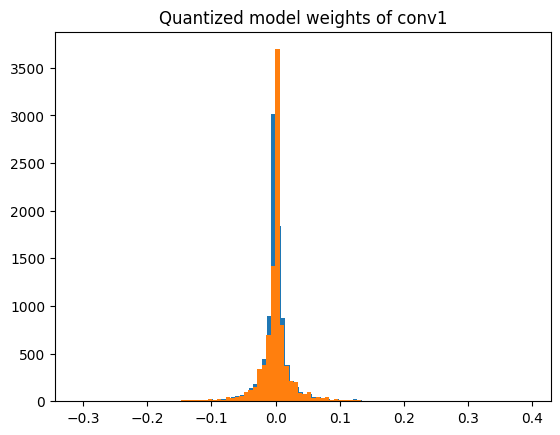

In [27]:
import matplotlib.pyplot as plt

f = wt_compare_dict['conv1.weight']['float'].flatten()
plt.hist(f, bins = 100)

q = wt_compare_dict['conv1.weight']['quantized'].flatten().dequantize()
plt.hist(q, bins = 100)
plt.title("Quantized model weights of conv1")
plt.show()

### RECOMMENDATIONS FOR YOUR WORKFLOW

![](https://drive.google.com/uc?export=view&id=1ij7GElwiKFNmJ221aKpkDRwMj5i-2DLh)



*   Large (10M+ parameters) models are more robust to quantization error
*   Quantizing a model from a FP32 checkpoint provides better accuracy than training an INT8 model from scratch
*   Dynamic Quantization is an easy first step, especially if your model has many Linear or Recurrent layers
*   Use symmetric-per-channel quantization with MinMax observers for quantizing weights. Use affine-per-tensor quantization with MovingAverageMinMax observers for quantizing activations
*   Use metrics like SQNR to identify which layers are most suscpetible to quantization error. Turn off quantization on these layers

Eager mode https://pytorch.org/docs/stable/quantization.html#eager-mode-quantization



*   https://pytorch.org/docs/stable/quantization.html#post-training-dynamic-quantization
*   https://pytorch.org/docs/stable/quantization.html#post-training-static-quantization


FX Graph https://pytorch.org/docs/stable/quantization.html#prototype-fx-graph-mode-quantization



*   https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_static.html
*   https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_dynamic.html





## New workflow with torchao



In [28]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('torchao') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'torchao'], check=False)
else:
    print('torchao already installed')


torchao already installed


In [29]:
import copy
import os
import torch

class ToyLinearModel(torch.nn.Module):
    def __init__(self, m: int, n: int, k: int):
        super().__init__()
        self.linear1 = torch.nn.Linear(m, n, bias=False)
        self.linear2 = torch.nn.Linear(n, k, bias=False)

    def forward(self, x):
        x = self.linear1(x)
        x = self.linear2(x)
        return x

model = ToyLinearModel(1024, 1024, 1024).eval().cuda()
if os.environ.get('SEMINAR_USE_COMPILE', '0') == '1':
    try:
        model = torch.compile(model, mode='max-autotune', fullgraph=True)
    except Exception as e:
        print(f'torch.compile skipped: {e}')
else:
    print('torch.compile disabled for stable notebook run')
model_f32 = copy.deepcopy(model)


torch.compile disabled for stable notebook run


In [30]:
try:
    from torchao.quantization import quantize_
    try:
        from torchao.quantization import Int4WeightOnlyConfig as _Int4Cfg
    except ImportError:
        from torchao.quantization import Float8DynamicActivationInt4WeightConfig as _Int4Cfg
    quantize_(model, _Int4Cfg())
    print('torchao int4/weight-only quantization applied:', _Int4Cfg.__name__)
except Exception as e:
    print(f'torchao quantization skipped: {e}')


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.5.1+cu124).


torchao quantization skipped: module 'torch' has no attribute 'int1'


In [31]:
import time

def _bench_ms(fn, example_inputs, n_warmup=10, n_runs=50):
    fn.eval()
    with torch.inference_mode():
        for _ in range(n_warmup):
            fn(*example_inputs)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n_runs):
            fn(*example_inputs)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        return (time.perf_counter() - t0) / n_runs * 1000

try:
    example_inputs = (torch.randn(1, 1024, device=next(model.parameters()).device),)
    f32_time = _bench_ms(model_f32, example_inputs)
    int4_time = _bench_ms(model, example_inputs)
    print('f32 mean time: %.3f ms' % f32_time)
    print('quantized mean time: %.3f ms' % int4_time)
    print('speedup: %.1fx' % (f32_time / int4_time))
except Exception as e:
    print(f'benchmark skipped: {e}')


f32 mean time: 0.022 ms
quantized mean time: 0.022 ms
speedup: 1.0x


In [32]:
import os
torch.save(model, "/tmp/int4_model.pt")
torch.save(model_f32, "/tmp/f32_model.pt")
int4_model_size_mb = os.path.getsize("/tmp/int4_model.pt") / 1024 / 1024
f32_model_size_mb = os.path.getsize("/tmp/f32_model.pt") / 1024 / 1024

print("int4 model size: %.2f MB" % int4_model_size_mb)

print("f32 model size: %.2f MB" % f32_model_size_mb)


int4 model size: 8.00 MB
f32 model size: 8.00 MB


### Neural Network Compression Framework (NNCF)

In [33]:
import os
import subprocess
import sys

if not os.path.isdir('nncf'):
    subprocess.run(
        ['git', 'clone', 'https://github.com/openvinotoolkit/nncf'],
        check=False,
    )
else:
    print('nncf directory already exists, skipping clone')


nncf directory already exists, skipping clone


In [34]:
import importlib.util
import os
import subprocess
import sys

if importlib.util.find_spec('nncf') is None:
    nncf_dir = os.path.abspath('nncf')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-e', f'{nncf_dir}[torch]'],
        check=False,
    )
else:
    print('nncf already installed, skipping pip install')


nncf already installed, skipping pip install


In [35]:
import torch
import nncf.torch  # Important - must be imported before any other external package that depends on torch

https://github.com/openvinotoolkit/nncf/tree/develop
https://github.com/openvinotoolkit/nncf/blob/develop/docs/compression_algorithms/Quantization.md
https://github.com/openvinotoolkit/nncf/blob/develop/examples/torch/classification/configs/quantization/inception_v3_imagenet_int8.json

https://dev-discuss.pytorch.org/t/torch-ao-quantization-migration-plan/2810
https://docs.pytorch.org/ao/stable

**Домашнее задание**: реализовать Post Training Quantization для предобученной float32 torch2 модели на выбранном наборе данных. Квантизация обязательно должна проводиться с использованием калибровочной подвыборки. К результатам прилагаются мини результаты исследования влияния гиперпараметров квантизации (см. начало ноутбка). Необходимо показать разные варианты с учетом и без SENSITIVITY анализа. Разрешается использовать дополнительные фреймворки после обсуждения. Важно наличие таблиц скорость / качество / размер.

| Method | Size (MB) | Metric | Latency (ms) | Notes |
|--------|-----------|--------|--------------|-------|
| FP32 baseline | | | | |
| PTQ static (uniform qconfig) | | | | calibration subset |
| PTQ + sensitivity analysis | | | | per-layer qconfig |

| Method | Size (MB) | Metric | Latency (ms) | Notes |
|--------|-----------|--------|--------------|-------|
| FP32 baseline | | | | |
| PTQ static (uniform qconfig) | | | | calibration subset |
| PTQ + sensitivity analysis | | | | per-layer qconfig |

| Method | Size (MB) | Metric | Latency (ms) | Notes |
|--------|-----------|--------|--------------|-------|
| FP32 baseline | | | | |
| PTQ static (uniform qconfig) | | | | calibration subset |
| PTQ + sensitivity analysis | | | | per-layer qconfig |

| Method | Size (MB) | Metric | Latency (ms) | Notes |
|--------|-----------|--------|--------------|-------|
| FP32 baseline | | | | |
| PTQ static (uniform qconfig) | | | | calibration subset |
| PTQ + sensitivity analysis | | | | per-layer qconfig |
